In [1]:
# ============================================================
# Deep Learning for PAMAP2 Human Activity Recognition
# ============================================================
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print("Random seed fixed.")

Random seed fixed.


In [19]:
# ============================================================
# ============================================================
# Load Windowed Dataset
# ============================================================

DATA_PATH = "/lustre09/project/6081099/reem2005/DATASET"

X = np.load(f"{DATA_PATH}/X_windows.npy")
y = np.load(f"{DATA_PATH}/y_windows.npy")
groups = np.load(f"{DATA_PATH}/groups.npy")

print(X.shape)
print(y.shape)
print(groups.shape)
subjects = groups  
print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("Activities :", np.unique(y))


(28727, 100, 18)
(28727,)
(28727,)
Dataset Loaded Successfully
Activities : [0 1 2 3 4 5 6 7]


In [20]:
# ============================================================
# Encode Labels
# ============================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

NUM_CLASSES = len(np.unique(y))

print(np.unique(y))
print(NUM_CLASSES)

[0 1 2 3 4 5 6 7]
8


In [21]:
unique_labels = np.unique(y)
label_map = {old: new for new, old in enumerate(unique_labels)}
y = np.array([label_map[v] for v in y])
NUM_CLASSES = len(unique_labels)

print("Label map    :", label_map)
print("NUM_CLASSES  :", NUM_CLASSES)

Label map    : {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7}
NUM_CLASSES  : 8


In [22]:
print("="*60)
print("Dataset Summary")
print("="*60)

print(f"Samples        : {len(X)}")
print(f"Window Size    : {X.shape[1]}")
print(f"Features       : {X.shape[2]}")
print(f"Classes        : {len(np.unique(y))}")
print(f"Subjects       : {len(np.unique(groups))}")

Dataset Summary
Samples        : 28727
Window Size    : 100
Features       : 18
Classes        : 8
Subjects       : 8


In [23]:
# ============================================================
# PyTorch Dataset
# ============================================================

from torch.utils.data import Dataset

class HARDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [24]:
# ============================================================
# Hyperparameters
# ============================================================
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 7            # early stopping patience
GRAD_CLIP_NORM = 5.0
RANDOM_SEED = SEED

INPUT_WINDOW = X.shape[1]   # هيك رح تطلع 100
INPUT_FEATURES = X.shape[2] # هيك رح تطلع 18

print("Window size :", INPUT_WINDOW)
print("Features    :", INPUT_FEATURES)

Window size : 100
Features    : 18


In [25]:
# ============================================================
# Leave-One-Subject-Out
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

In [26]:
# ============================================================
# Dataset Class
# ============================================================

class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## Model Zoo
Five architectures are defined below, all sharing the same input shape 
(batch, window, features) and output shape (batch, num_classes):
- DNN — fully-connected baseline, ignores temporal order
- CNN1D — 1D convolutions over the time axis, captures local patterns
- RNN — vanilla recurrent network, baseline for comparison against LSTM
- LSTM — gated recurrent network, standard choice for HAR
- DeepConvLSTM — CNN feature extractor + LSTM temporal model

In [27]:
class DNNClassifier(nn.Module):
    def __init__(self, window, features, num_classes):
        super().__init__()
        input_dim = window * features
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

CNN1D
Note: 1D convolutions slide over the time axis, treating each sensor channel as an input channel. Good at detecting local temporal patterns (e.g. a step) regardless of where they occur in the window.

In [28]:
class CNN1DClassifier(nn.Module):
    def __init__(self, window, features, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
        )
        conv_out_len = window // 4  # two MaxPool1d(2) layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * conv_out_len, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (batch, window, features) -> (batch, features, window)
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        return self.classifier(x)

RNN
Note: Vanilla RNN baseline for comparison against the gated LSTM version. Usually weaker due to vanishing gradients over longer sequences — included specifically to demonstrate that gap.

In [29]:
class RNNClassifier(nn.Module):
    def __init__(self, window, features, num_classes, hidden_size=128):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=features,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            nonlinearity="tanh",
        )
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, hidden = self.rnn(x)
        x = self.dropout(hidden[-1])
        return self.classifier(x)

 DeepConvLSTM
Note: Convolutional feature extractor followed by an LSTM temporal model — convolutions learn local sensor patterns, the LSTM learns how those patterns evolve across the window. Usually the strongest architecture for HAR, but also the most prone to overfitting with few subjects.

In [30]:
class DeepConvLSTMClassifier(nn.Module):
    def __init__(self, window, features, num_classes, conv_channels=64, lstm_hidden=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(features, conv_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),

            nn.Conv1d(conv_channels, conv_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
        )
        self.dropout = nn.Dropout(0.4)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        _, (hidden, _) = self.lstm(x)
        x = self.dropout(hidden[-1])
        return self.classifier(x)

Model Registry
Note: A dictionary mapping model names to their classes, used later to loop over all architectures automatically.

In [31]:
MODEL_REGISTRY = {
    "dnn": DNNClassifier,
    "cnn1d": CNN1DClassifier,
    "rnn": RNNClassifier,
    "deepconv_lstm": DeepConvLSTMClassifier,
}

## Training & Evaluation Utilities
train_one_epoch() runs one full pass over the training data, updating 
weights. evaluate() runs one full pass without gradient updates, used 
for both validation and final test scoring.

train_one_epoch + evaluateNote: Both functions return loss, accuracy, and macro F1. Gradient clipping is applied during training to prevent unstable updates.

In [32]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    predictions, labels = [], []

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        running_loss += loss.item()
        predictions.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(labels, predictions)
    epoch_f1 = f1_score(labels, predictions, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    predictions, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()
            predictions.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(labels, predictions)
    epoch_f1 = f1_score(labels, predictions, average="macro")
    return epoch_loss, epoch_acc, epoch_f1, labels, predictions

## Leakage-Free LOSO Experiment Runner
For every held-out test subject:
1. One other subject is drawn from the remaining training subjects to 
   act as an inner validation set — used only to pick the best epoch 
   and trigger early stopping.
2. The scaler is fit on the training subjects only.
3. The best-epoch model is evaluated once on the untouched test subject.
This mirrors real deployment: the model never sees the subject it will 
be judged on until final scoring.

run_loso_experiment()
Note: Runs the full LOSO cross-validation for a single model name. Returns per-fold F1 scores plus all predictions/labels for later aggregation.

In [33]:
def run_loso_experiment(model_name, epochs=EPOCHS, verbose=True):
    assert model_name in MODEL_REGISTRY, f"Unknown model: {model_name}"
    model_cls = MODEL_REGISTRY[model_name]

    logo = LeaveOneGroupOut()
    fold_results = []
    all_predictions, all_labels = [], []

    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, subjects), start=1):
        # ---- inner train/val split (no leakage into test) ----
        train_subjects_all = np.unique(subjects[train_idx])
        rng = np.random.RandomState(RANDOM_SEED + fold)
        val_subject = rng.choice(train_subjects_all)

        inner_val_mask = subjects[train_idx] == val_subject
        inner_train_mask = ~inner_val_mask

        real_train_idx = train_idx[inner_train_mask]
        inner_val_idx = train_idx[inner_val_mask]

        X_train, y_train = X[real_train_idx], y[real_train_idx]
        X_val, y_val = X[inner_val_idx], y[inner_val_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        # ---- scale: fit on train only ----
        scaler = StandardScaler()
        scaler.fit(X_train.reshape(-1, X_train.shape[-1]))

        def scale(arr):
            shp = arr.shape
            return scaler.transform(arr.reshape(-1, shp[-1])).reshape(shp)

        X_train, X_val, X_test = scale(X_train), scale(X_val), scale(X_test)

        # ---- loaders ----
        train_loader = DataLoader(HARDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(HARDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
        test_loader  = DataLoader(HARDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

        # ---- model ----
        model = model_cls(INPUT_WINDOW, INPUT_FEATURES, NUM_CLASSES).to(device)

        # ---- class weights from train labels only ----
        classes_present = np.unique(y_train)
        weights = compute_class_weight("balanced", classes=classes_present, y=y_train)
        full_weights = np.ones(NUM_CLASSES, dtype=np.float32)
        for c, w in zip(classes_present, weights):
            full_weights[c] = w
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(full_weights, device=device))

        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

        best_f1, best_model, patience_counter = 0.0, None, 0

        for epoch in range(epochs):
            train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
            scheduler.step(val_f1)

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_model = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if verbose:
                print(
                    f"[{model_name}] Fold {fold} | Epoch {epoch+1}/{epochs} | "
                    f"Train Acc={train_acc:.3f} | InnerVal F1={val_f1:.3f}"
                )

            if patience_counter >= PATIENCE:
                if verbose:
                    print(f"[{model_name}] Fold {fold} | early stopping at epoch {epoch+1}")
                break

        if best_model is not None:
            model.load_state_dict(best_model)

        _, test_acc, test_f1, test_labels, test_preds = evaluate(model, test_loader, criterion, device)
        print(f"==> [{model_name}] Fold {fold} FINAL TEST | Acc={test_acc:.4f} | F1={test_f1:.4f}")

        fold_results.append(test_f1)
        all_predictions.extend(test_preds)
        all_labels.extend(test_labels)

        del model
        torch.cuda.empty_cache()

    return {
        "model_name": model_name,
        "fold_f1s": np.array(fold_results),
        "mean_f1": float(np.mean(fold_results)),
        "std_f1": float(np.std(fold_results)),
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_predictions),
    }

## Run the Comparison
Trains every model in MODEL_REGISTRY using the same LOSO protocol.
This is the actual training step — it will take a while since it 
trains 4 models × 8 folds, each up to 30 epochs (with early stopping).
Progress prints one line per fold showing the final test accuracy/F1.

In [34]:
set_seed(SEED)  # reset before each full comparison run for reproducibility

all_results = {}
for model_name in MODEL_REGISTRY:
    print("\n" + "=" * 70)
    print(f"Training model: {model_name.upper()}")
    print("=" * 70)
    all_results[model_name] = run_loso_experiment(model_name, epochs=EPOCHS, verbose=False)


Training model: DNN
==> [dnn] Fold 1 FINAL TEST | Acc=0.7158 | F1=0.7051
==> [dnn] Fold 2 FINAL TEST | Acc=0.6401 | F1=0.5734
==> [dnn] Fold 3 FINAL TEST | Acc=0.8582 | F1=0.8470
==> [dnn] Fold 4 FINAL TEST | Acc=0.7420 | F1=0.7359
==> [dnn] Fold 5 FINAL TEST | Acc=0.7566 | F1=0.7442
==> [dnn] Fold 6 FINAL TEST | Acc=0.8137 | F1=0.8041
==> [dnn] Fold 7 FINAL TEST | Acc=0.8079 | F1=0.7836
==> [dnn] Fold 8 FINAL TEST | Acc=0.5277 | F1=0.4705

Training model: CNN1D
==> [cnn1d] Fold 1 FINAL TEST | Acc=0.7348 | F1=0.7211
==> [cnn1d] Fold 2 FINAL TEST | Acc=0.6569 | F1=0.6017
==> [cnn1d] Fold 3 FINAL TEST | Acc=0.8755 | F1=0.8596
==> [cnn1d] Fold 4 FINAL TEST | Acc=0.8126 | F1=0.8093
==> [cnn1d] Fold 5 FINAL TEST | Acc=0.8049 | F1=0.7997
==> [cnn1d] Fold 6 FINAL TEST | Acc=0.8218 | F1=0.8116
==> [cnn1d] Fold 7 FINAL TEST | Acc=0.8384 | F1=0.8140
==> [cnn1d] Fold 8 FINAL TEST | Acc=0.3309 | F1=0.2720

Training model: RNN
==> [rnn] Fold 1 FINAL TEST | Acc=0.7112 | F1=0.6894
==> [rnn] Fold 2 F

In [35]:
summary_rows = []
for name, res in all_results.items():
    acc = accuracy_score(res["y_true"], res["y_pred"])
    summary_rows.append({
        "model": name,
        "mean_f1_macro": res["mean_f1"],
        "std_f1_macro": res["std_f1"],
        "overall_accuracy": acc,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean_f1_macro", ascending=False).reset_index(drop=True)
summary_df

,model,mean_f1_macro,std_f1_macro,overall_accuracy
0,deepconv_lstm,0.721452,0.157128,0.740175
1,cnn1d,0.711132,0.182036,0.733247
2,dnn,0.707981,0.117743,0.731646
3,rnn,0.650135,0.152891,0.681415


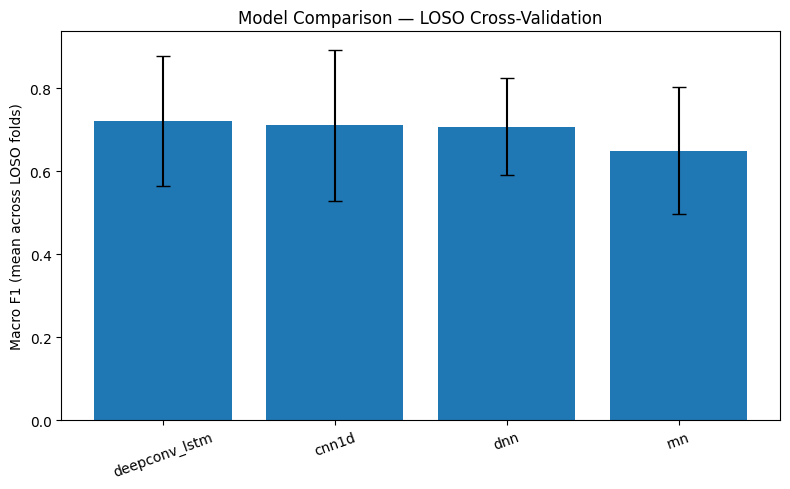

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["mean_f1_macro"], yerr=summary_df["std_f1_macro"], capsize=5)
plt.ylabel("Macro F1 (mean across LOSO folds)")
plt.title("Model Comparison — LOSO Cross-Validation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

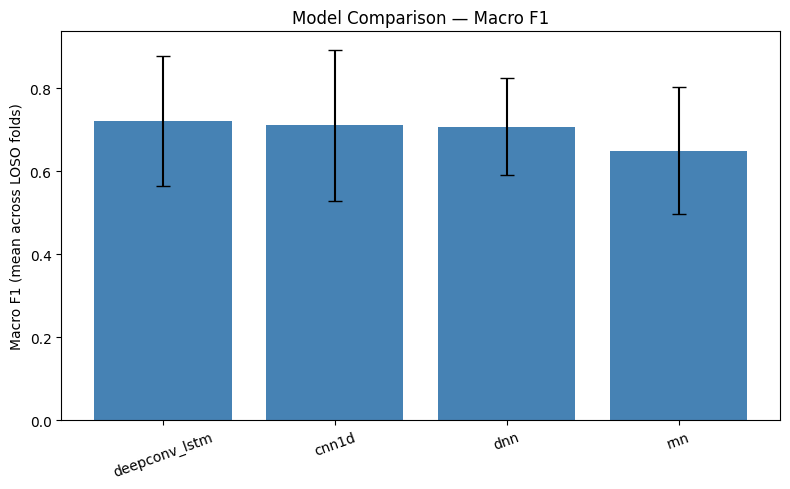

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["mean_f1_macro"],
        yerr=summary_df["std_f1_macro"], capsize=5, color="steelblue")
plt.ylabel("Macro F1 (mean across LOSO folds)")
plt.title("Model Comparison — Macro F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1960848/4152822476.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(fold_data, labels=model_names)


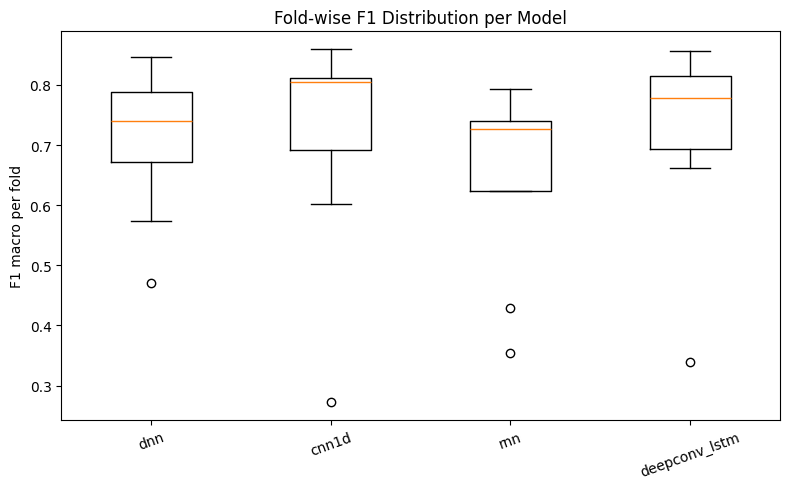

In [38]:
fold_data = [all_results[name]["fold_f1s"] for name in all_results]
model_names = list(all_results.keys())

plt.figure(figsize=(8, 5))
plt.boxplot(fold_data, labels=model_names)
plt.ylabel("F1 macro per fold")
plt.title("Fold-wise F1 Distribution per Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

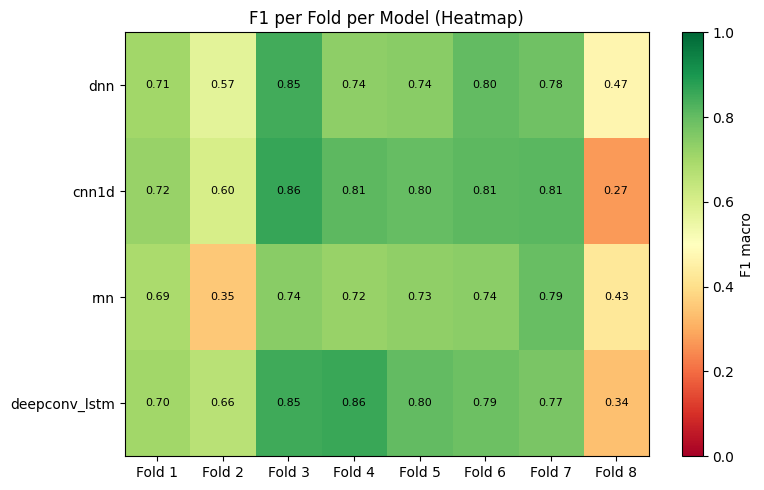

In [39]:
import numpy as np

fold_matrix = np.array([all_results[name]["fold_f1s"] for name in model_names])

plt.figure(figsize=(8, 5))
im = plt.imshow(fold_matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, label="F1 macro")
plt.yticks(range(len(model_names)), model_names)
plt.xticks(range(fold_matrix.shape[1]), [f"Fold {i+1}" for i in range(fold_matrix.shape[1])])
plt.title("F1 per Fold per Model (Heatmap)")

for i in range(fold_matrix.shape[0]):
    for j in range(fold_matrix.shape[1]):
        plt.text(j, i, f"{fold_matrix[i,j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

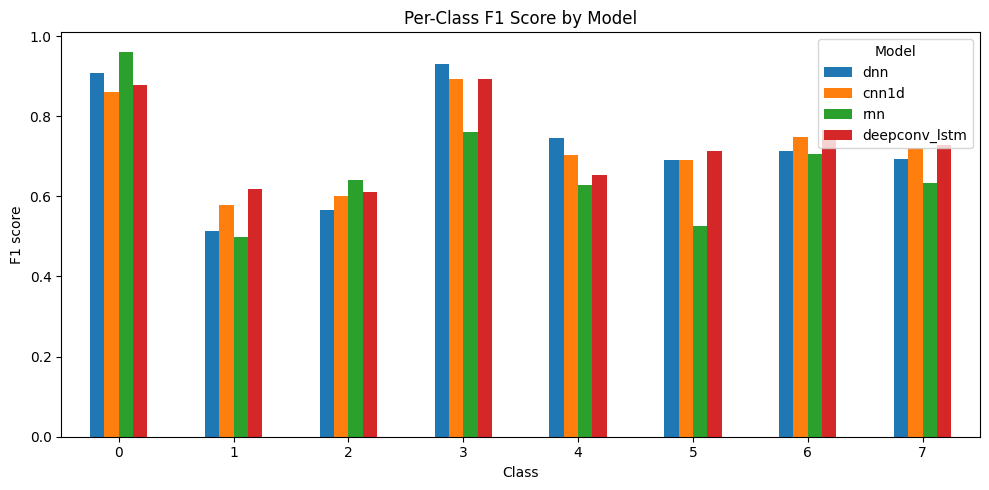

,dnn,cnn1d,rnn,deepconv_lstm
Class,,,,
0,0.908128,0.861310,0.961238,0.878564
1,0.514514,0.577144,0.497872,0.618117
2,0.564863,0.602032,0.641905,0.610515
3,0.930278,0.891861,0.760889,0.892220
4,0.744332,0.703926,0.629230,0.653400
5,0.690449,0.689864,0.525973,0.712108
6,0.712022,0.747101,0.705477,0.766026
7,0.693558,0.720926,0.632837,0.726959


In [40]:
from sklearn.metrics import f1_score

class_f1_data = {}
for name in model_names:
    res = all_results[name]
    per_class_f1 = f1_score(res["y_true"], res["y_pred"], average=None)
    class_f1_data[name] = per_class_f1

class_f1_df = pd.DataFrame(class_f1_data)
class_f1_df.index.name = "Class"

class_f1_df.plot(kind="bar", figsize=(10, 5))
plt.ylabel("F1 score")
plt.title("Per-Class F1 Score by Model")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

class_f1_df

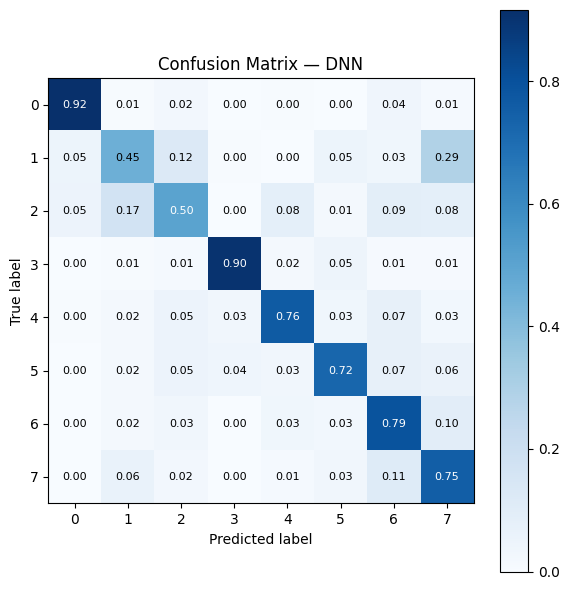

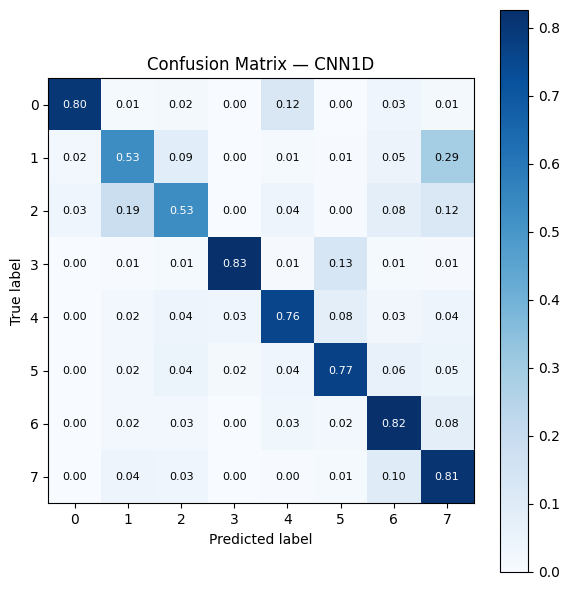

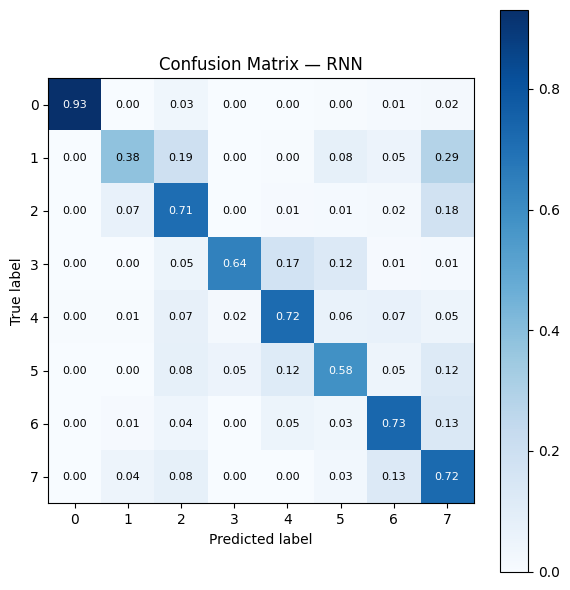

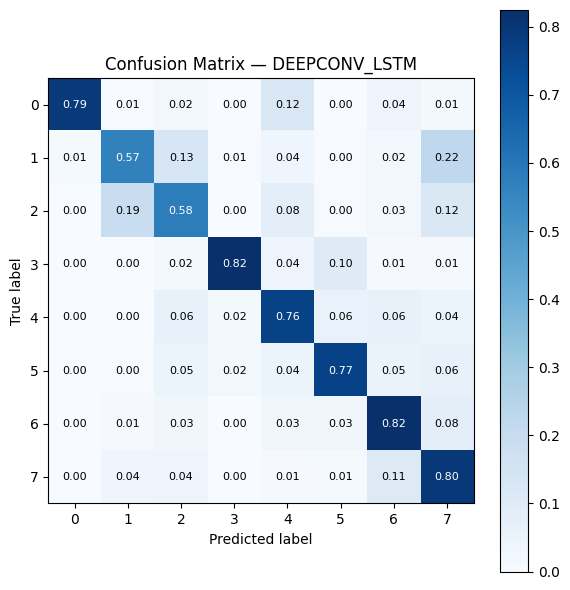

In [41]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title, normalize=True):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.colorbar(im, ax=ax)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=8)
    plt.tight_layout()
    plt.show()

for name, res in all_results.items():
    plot_confusion_matrix(res["y_true"], res["y_pred"], title=f"Confusion Matrix — {name.upper()}")

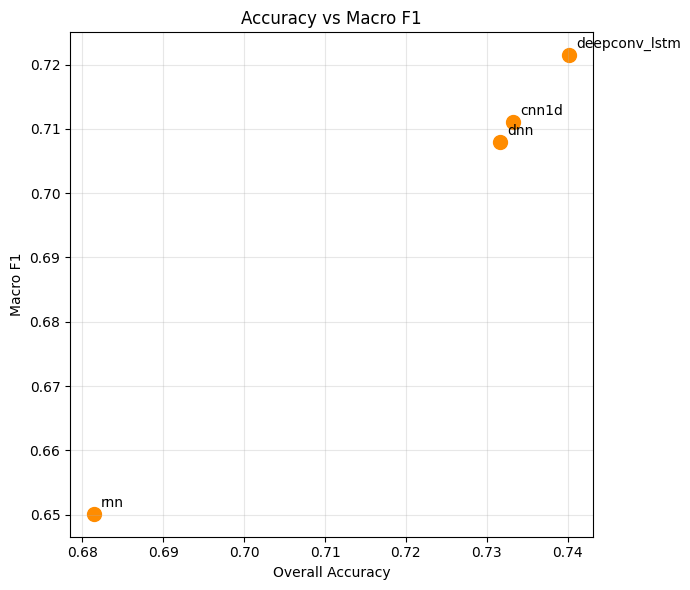

In [42]:
plt.figure(figsize=(7, 6))
plt.scatter(summary_df["overall_accuracy"], summary_df["mean_f1_macro"], s=100, color="darkorange")

for i, row in summary_df.iterrows():
    plt.annotate(row["model"], (row["overall_accuracy"], row["mean_f1_macro"]),
                 textcoords="offset points", xytext=(5, 5))

plt.xlabel("Overall Accuracy")
plt.ylabel("Macro F1")
plt.title("Accuracy vs Macro F1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
detailed_df = summary_df.copy()
detailed_df["min_fold_f1"] = [all_results[m]["fold_f1s"].min() for m in detailed_df["model"]]
detailed_df["max_fold_f1"] = [all_results[m]["fold_f1s"].max() for m in detailed_df["model"]]
detailed_df

,model,mean_f1_macro,std_f1_macro,overall_accuracy,min_fold_f1,max_fold_f1
0,deepconv_lstm,0.721452,0.157128,0.740175,0.339795,0.855886
1,cnn1d,0.711132,0.182036,0.733247,0.272010,0.859616
2,dnn,0.707981,0.117743,0.731646,0.470511,0.847015
3,rnn,0.650135,0.152891,0.681415,0.353892,0.793043


TinyHAR Model
Note: A lightweight architecture inspired by the TinyHAR design (Zhou et al., ISWC 2022): cross-channel convolution to fuse sensor channels, a temporal encoder (Conv1D + LSTM) to capture dynamics, and attention-based temporal pooling instead of just taking the last hidden state

In [45]:
class TinyHARClassifier(nn.Module):
    def __init__(self, window, features, num_classes,
                 cross_channels=32, lstm_hidden=64):
        super().__init__()

        # Cross-channel interaction: learn relationships between sensor
        # channels before looking at time.
        self.cross_channel = nn.Sequential(
            nn.Conv1d(features, cross_channels, kernel_size=1),
            nn.BatchNorm1d(cross_channels),
            nn.ReLU(),
        )

        # Lightweight temporal feature extractor
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(cross_channels, cross_channels, kernel_size=5, padding=2, groups=cross_channels),
            nn.BatchNorm1d(cross_channels),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.lstm = nn.LSTM(
            input_size=cross_channels,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
        )

        # Attention-based temporal pooling: instead of only using the last
        # LSTM hidden state, learn a weighted combination over all timesteps.
        self.attn = nn.Linear(lstm_hidden, 1)

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(lstm_hidden, num_classes)

    def forward(self, x):
        # x: (batch, window, features) -> (batch, features, window)
        x = x.permute(0, 2, 1)
        x = self.cross_channel(x)
        x = self.temporal_conv(x)
        x = x.permute(0, 2, 1)  # (batch, window, cross_channels)

        lstm_out, _ = self.lstm(x)  # (batch, window, lstm_hidden)

        attn_scores = self.attn(lstm_out)               # (batch, window, 1)
        attn_weights = torch.softmax(attn_scores, dim=1) # over time
        context = (lstm_out * attn_weights).sum(dim=1)   # (batch, lstm_hidden)

        x = self.dropout(context)
        return self.classifier(x)

In [46]:
# تسجيل مؤقت، بدون التأثير على MODEL_REGISTRY الأصلي
MODEL_REGISTRY["tinyhar"] = TinyHARClassifier

tinyhar_result = run_loso_experiment("tinyhar", epochs=EPOCHS, verbose=False)

print("TinyHAR mean F1:", tinyhar_result["mean_f1"])
print("TinyHAR std F1 :", tinyhar_result["std_f1"])

==> [tinyhar] Fold 1 FINAL TEST | Acc=0.7132 | F1=0.6978
==> [tinyhar] Fold 2 FINAL TEST | Acc=0.6798 | F1=0.6302
==> [tinyhar] Fold 3 FINAL TEST | Acc=0.8631 | F1=0.8540
==> [tinyhar] Fold 4 FINAL TEST | Acc=0.7677 | F1=0.7470
==> [tinyhar] Fold 5 FINAL TEST | Acc=0.8084 | F1=0.8048
==> [tinyhar] Fold 6 FINAL TEST | Acc=0.8165 | F1=0.8132
==> [tinyhar] Fold 7 FINAL TEST | Acc=0.8047 | F1=0.7543
==> [tinyhar] Fold 8 FINAL TEST | Acc=0.6504 | F1=0.6208
TinyHAR mean F1: 0.7402557126563533
TinyHAR std F1 : 0.079740316443364


In [47]:
all_results["tinyhar"] = tinyhar_result

summary_rows = []
for name, res in all_results.items():
    acc = accuracy_score(res["y_true"], res["y_pred"])
    summary_rows.append({
        "model": name,
        "mean_f1_macro": res["mean_f1"],
        "std_f1_macro": res["std_f1"],
        "overall_accuracy": acc,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean_f1_macro", ascending=False).reset_index(drop=True)
summary_df

,model,mean_f1_macro,std_f1_macro,overall_accuracy
0,tinyhar,0.740256,0.079740,0.762558
1,deepconv_lstm,0.721452,0.157128,0.740175
2,cnn1d,0.711132,0.182036,0.733247
3,dnn,0.707981,0.117743,0.731646
4,rnn,0.650135,0.152891,0.681415


In [49]:
tinyhar_acc = accuracy_score(tinyhar_result["y_true"], tinyhar_result["y_pred"])
print(f"TinyHAR Overall Accuracy: {tinyhar_acc:.4f}")

TinyHAR Overall Accuracy: 0.7626


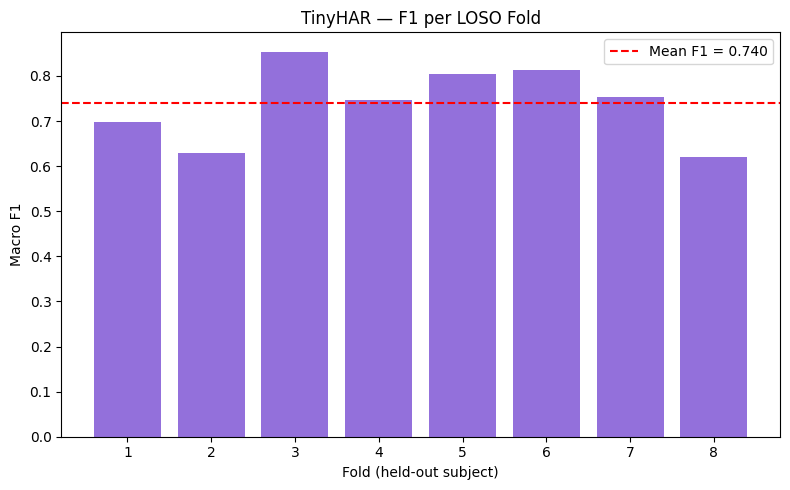

In [48]:
plt.figure(figsize=(8, 5))
folds = range(1, len(tinyhar_result["fold_f1s"]) + 1)
plt.bar(folds, tinyhar_result["fold_f1s"], color="mediumpurple")
plt.axhline(tinyhar_result["mean_f1"], color="red", linestyle="--",
            label=f'Mean F1 = {tinyhar_result["mean_f1"]:.3f}')
plt.xlabel("Fold (held-out subject)")
plt.ylabel("Macro F1")
plt.title("TinyHAR — F1 per LOSO Fold")
plt.xticks(list(folds))
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
print(classification_report(tinyhar_result["y_true"], tinyhar_result["y_pred"], digits=4))

              precision    recall  f1-score   support

           0     0.9704    0.9148    0.9418      3837
           1     0.7263    0.4622    0.5649      3691
           2     0.6530    0.7331    0.6907      3788
           3     0.9548    0.8511    0.9000      4763
           4     0.7065    0.8105    0.7549      2322
           5     0.7349    0.7104    0.7225      2072
           6     0.7544    0.8151    0.7836      3494
           7     0.6284    0.7683    0.6913      4760

    accuracy                         0.7626     28727
   macro avg     0.7661    0.7582    0.7562     28727
weighted avg     0.7733    0.7626    0.7617     28727



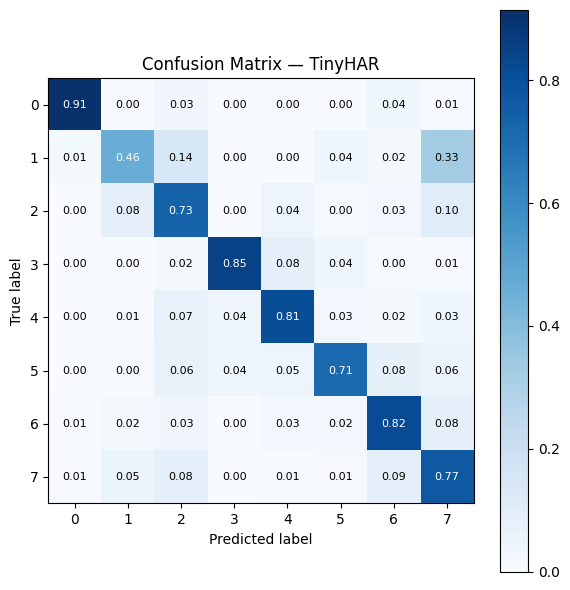

In [51]:
plot_confusion_matrix(
    tinyhar_result["y_true"],
    tinyhar_result["y_pred"],
    title="Confusion Matrix — TinyHAR"
)

In [52]:
fold_df = pd.DataFrame({
    "Fold": range(1, len(tinyhar_result["fold_f1s"]) + 1),
    "F1_macro": tinyhar_result["fold_f1s"]
})
fold_df

,Fold,F1_macro
0,1,0.697827
1,2,0.630158
2,3,0.854003
3,4,0.747002
4,5,0.804788
5,6,0.813186
6,7,0.754329
7,8,0.620752


In [53]:
print(f"Mean F1 macro : {tinyhar_result['mean_f1']:.4f} (+/- {tinyhar_result['std_f1']:.4f})")
print(f"Overall Accuracy : {tinyhar_acc:.4f}")

Mean F1 macro : 0.7403 (+/- 0.0797)
Overall Accuracy : 0.7626
